#Lab - 3

Device: cuda
Epoch 1/50 | Train: 192.4803 | Val: 130.4991
Epoch 2/50 | Train: 118.9834 | Val: 110.9393
Epoch 3/50 | Train: 109.2966 | Val: 106.3570
Epoch 4/50 | Train: 106.2011 | Val: 104.7043
Epoch 5/50 | Train: 104.6875 | Val: 103.3240
Epoch 6/50 | Train: 103.6399 | Val: 102.4746
Epoch 7/50 | Train: 102.8226 | Val: 101.7849
Epoch 8/50 | Train: 102.2707 | Val: 101.3057
Epoch 9/50 | Train: 101.7366 | Val: 101.1011
Epoch 10/50 | Train: 101.3270 | Val: 100.5444
Epoch 11/50 | Train: 100.9526 | Val: 100.2637
Epoch 12/50 | Train: 100.5702 | Val: 99.9648
Epoch 13/50 | Train: 100.2806 | Val: 99.7284
Epoch 14/50 | Train: 99.9952 | Val: 99.5344
Epoch 15/50 | Train: 99.8301 | Val: 99.2554
Epoch 16/50 | Train: 99.5876 | Val: 99.1066
Epoch 17/50 | Train: 99.3675 | Val: 98.9241
Epoch 18/50 | Train: 99.2084 | Val: 98.6511
Epoch 19/50 | Train: 99.0220 | Val: 98.4228
Epoch 20/50 | Train: 98.8230 | Val: 98.2812
Epoch 21/50 | Train: 98.6514 | Val: 98.4065
Epoch 22/50 | Train: 98.5367 | Val: 98.0983
Epoc

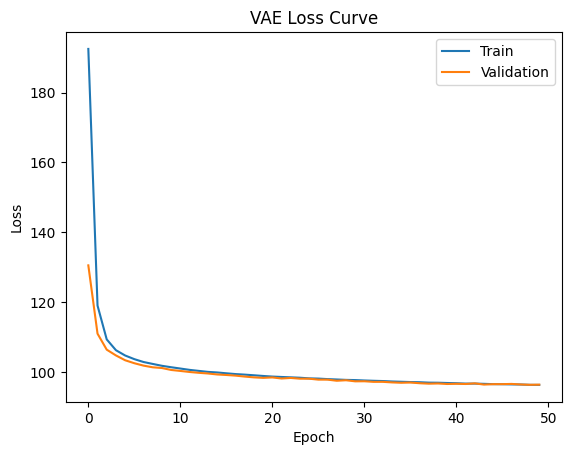

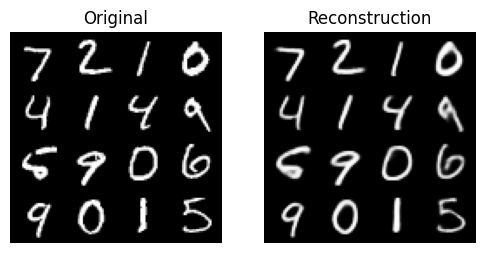

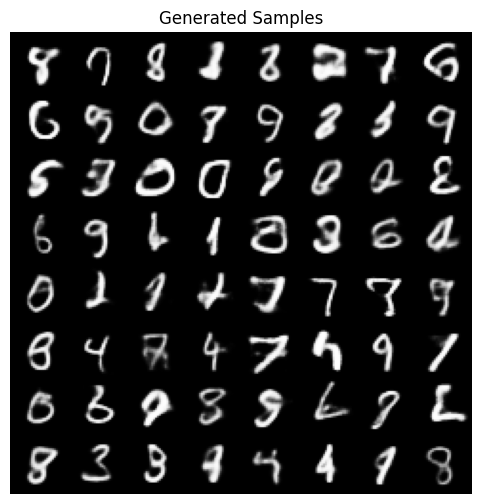

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 128
epochs = 50
learning_rate = 5e-4
latent_dim = 32
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU()
        )

        self.enc_dim = 128 * 4 * 4
        self.fc_mu = nn.Linear(self.enc_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.enc_dim, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, self.enc_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 128, 4, 4)
        return self.decoder(h)[:, :, :28, :28]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.BCELoss(reduction="sum")

def vae_loss(recon, x, mu, logvar):
    recon_loss = criterion(recon, x)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld, recon_loss, kld

train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0

    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, _, _ = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss, _, _ = vae_loss(recon, x, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/vae_mnist_improved.pth")

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE Loss Curve")
plt.show()

model.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.to(device)[:16]
    recon, _, _ = model(x)

orig = utils.make_grid(x.cpu(), nrow=4)
recon = utils.make_grid(recon.cpu(), nrow=4)

plt.figure(figsize=(6,6))
plt.subplot(1,2,1)
plt.imshow(orig.permute(1,2,0).squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(recon.permute(1,2,0).squeeze(), cmap="gray")
plt.title("Reconstruction")
plt.axis("off")
plt.show()

with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    samples = model.decode(z)

grid = utils.make_grid(samples.cpu(), nrow=8)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray")
plt.title("Generated Samples")
plt.axis("off")
plt.show()
